In [6]:
"""
-- 01_data_preparation.ipynb --
Análise:
    confirmação das contagens
    validação temporal
    validação dos identificadores
    dataset geográfico de postos com procura
    subset Coimbra
    primeiro mapa rápido
    ficheiros .parquet para reutilização

INPUTS:
    v01_sessoes_validas_clean
    v14_procura_posto_clean
    v30_features_cluster_posto_clean
    v51_postos_sem_procura
    v20_oferta_posto
    v01_postos_unicos_continente_all_data
    v00_caop_municipios
    
OUTPUTS:
    Alguns outputs foram ocultados propositadamente dado conterem informação sensível
"""


'\n-- 01_data_preparation.ipynb --\nAnálise:\n    confirmação das contagens\n    validação temporal\n    validação dos identificadores\n    dataset geográfico de postos com procura\n    subset Coimbra\n    primeiro mapa rápido\n    ficheiros .parquet para reutilização\n\nINPUTS:\n    v01_sessoes_validas\n    v20_oferta_posto\n'

In [ ]:
# ---------------------------------------
#           Setup e ligação à DB
# ---------------------------------------
import sys
import os

import pandas as pd
import geopandas as gpd
import numpy as np

from sqlalchemy import create_engine
from pathlib import Path

import matplotlib.pyplot as plt

# adicionar o caminho - sobe um nível
#sys.path.append(os.path.abspath(".."))
#print(os.getcwd())

# encontrar o caminho para a raiz do projeto (/projeto)
projeto_path = os.path.abspath(os.path.join(os.getcwd(), ".."))

# adicionar o novo caminho ao sys.path, caso ainda não esteja
if(projeto_path not in sys.path):
    sys.path.append(projeto_path)

# adicionar a pasta "projeto" ao sys.path
from db.config import DB_CONFIG
from sqlalchemy import create_engine

# função para criar a engine à bd remota
def get_engine():
    return create_engine(
        f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}@"
        f"{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['dbname']}"
    )

#from libs.map_utils import get_limites_distrito, plot_postos_distrito
import importlib
import libs.map_utils as munic
#importlib.reload(libs.map_utils)
importlib.reload(munic)

#from libs.map_utils import plot_postos_distrito

# definir o diretorio para guardar as figuras e quadros para o relatório
FIG_DIR = Path("../outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = Path("../outputs/tables")
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# cria a engine
engine = get_engine()
#print(engine)

In [ ]:
# ---------------------------------------
# Criação do ambiente para a análise
# ---------------------------------------
"""
    - variáveis para analisar: 
        -- por distrito
        -- gráfico - dimensão
        -- labels do gráfico
"""
# distrito
DISTRITO = "Coimbra"

# plot dos gráfics
FIGSIZE = (10, 10)
SHOW_LABELS = True

# variáveis para o mapa
VARIAVEIS_MAPA = [
    "n_sessoes",
    "energia_total_kwh",
    "sessoes_mes_ativo",
    "kwh_mes_ativo",
    "n_utilizadores_unicos",
    "sessoes_por_utilizador",
    "energia_media_kwh",
    "duracao_media_min"
]

In [ ]:
# ---------------------------------------
# Funções auxiliares
# ---------------------------------------
def read_sql(query):
    return pd.read_sql(query, engine)

def read_gdf(query, geom_col="geom"):
    return gpd.read_postgis(query, engine, geom_col=geom_col)

def anonymise_station_labels(df, id_col="id_charging_station", label_col="station_label"):
    """
        Creates anonymised station labels for sensivel data
    """
    df_out = df.copy()

    df_out[label_col] = [
        f"CS_{i:03d}"
        for i in range(1, len(df_out) + 1)
    ]

    return df_out

In [10]:
# Validate the key counts

queries = {
    "sessoes_validas": "SELECT COUNT(*) AS n FROM v01_sessoes_validas_clean",
    "postos_com_procura": "SELECT COUNT(*) AS n FROM v14_procura_posto_clean",
    "postos_instalados": "SELECT COUNT(*) AS n FROM v20_oferta_posto",
    "features_cluster": "SELECT COUNT(*) AS n FROM v30_features_cluster_posto_clean",
    "postos_sem_procura": "SELECT COUNT(*) AS n FROM v51_postos_sem_procura"
}

for name, query in queries.items():
    df = read_sql(query)
    print(f"{name}: {df.iloc[0,0]:,}")

sessoes_validas: 8,676,059
postos_com_procura: 9,309
postos_instalados: 16,674
features_cluster: 9,309
postos_sem_procura: 7,365


In [11]:
# Validação do período temporal
periodo = read_sql("""
SELECT
    MIN(start_date_time) AS inicio,
    MAX(start_date_time) AS fim,
    COUNT(DISTINCT mes) AS n_meses
FROM v01_sessoes_validas_clean
""")

periodo

,inicio,fim,n_meses
0,2023-01-30 18:48:14,2024-12-31 23:55:29,24


In [12]:
# Validação de sessões por ano
sessoes_ano = read_sql("""
SELECT
    ano,
    COUNT(*) AS n_sessoes,
    COUNT(DISTINCT id_charging_station) AS n_postos,
    COUNT(DISTINCT connector_id) AS n_conectores,
    COUNT(DISTINCT token_uid) AS n_tokens
FROM v01_sessoes_validas_clean
GROUP BY ano
ORDER BY ano
""")

sessoes_ano

,ano,n_sessoes,n_postos,n_conectores,n_tokens
0,2023,3116011,5687,19714,100934
1,2024,5560048,8733,15862,275111


In [13]:
# Validação do token_uid (apenas tem a partir de 2024)
tokens = read_sql("""
SELECT
    ano,
    COUNT(*) AS n_sessoes,
    COUNT(DISTINCT token_uid) AS n_tokens,
    SUM(tem_token_uid) AS sessoes_com_token
FROM v01_sessoes_validas_clean
GROUP BY ano
ORDER BY ano
""")

tokens

,ano,n_sessoes,n_tokens,sessoes_com_token
0,2023,3116011,100934,1314944
1,2024,5560048,275111,5560015


In [14]:
# Validação de EVSE estimado vs conectores
ids = read_sql("""
SELECT
    COUNT(DISTINCT evse_id_raw) AS evse_raw,
    COUNT(DISTINCT evse_uid_estimado) AS evse_estimado,
    COUNT(DISTINCT connector_id) AS conectores,
    COUNT(DISTINCT token_uid) AS tokens
FROM v01_sessoes_validas_clean
""")

ids

,evse_raw,evse_estimado,conectores,tokens
0,1819034,21154,25953,296094


In [15]:
# Leitura da amostra espacial
postos_procura = read_gdf("""
SELECT
    id_charging_station,
    distrito,
    municipio,
    n_sessoes,
    energia_total_kwh,
    sessoes_mes_ativo,
    kwh_mes_ativo,
    n_utilizadores_unicos,
    sessoes_por_utilizador,
    energia_media_kwh,
    duracao_media_min,
    geom
FROM v14_procura_posto_clean
""")

postos_procura.crs

<Projected CRS: EPSG:3763>
Name: ETRS89 / Portugal TM06
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: Portugal - mainland - onshore.
- bounds: (-9.56, 36.95, -6.19, 42.16)
Coordinate Operation:
- name: Portugual TM06
- method: Transverse Mercator
Datum: European Terrestrial Reference System 1989 ensemble
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [16]:
postos_procura = postos_procura.set_crs(epsg=3763, allow_override=True)

In [17]:
# Filtrar por DISTRITO :: Coimbra para testar
distrito_analisar = postos_procura[postos_procura["distrito"].str.upper() == DISTRITO.upper()].copy()
distrito_analisar.shape

distrito_analisar[[
    "id_charging_station",
    "municipio",
    "n_sessoes",
    "energia_total_kwh",
    "sessoes_mes_ativo",
    "kwh_mes_ativo",
    "n_utilizadores_unicos",
    "sessoes_por_utilizador",
    "energia_media_kwh",
    "duracao_media_min"
]].sort_values("n_sessoes", ascending=False).head(20)

top10 = (
    distrito_analisar.sort_values("n_sessoes", ascending=False)
      .head(10)
)

top10_pub = anonymise_station_labels(top10)

top10_pub[["station_label", "n_sessoes", "energia_total_kwh"]]

,station_label,n_sessoes,energia_total_kwh
1242,CS_001,10762,318267.553
1245,CS_002,9619,239551.261
1241,CS_003,8872,257814.966
1244,CS_004,6846,163289.206
1810,CS_005,6061,185082.292
1081,CS_006,5753,119845.497
1082,CS_007,5487,114426.770
1046,CS_008,5389,157207.822
1042,CS_009,5017,115436.460
1060,CS_010,4809,138711.569


In [18]:
# save do quadro como ficheiro latex para usar no overleaf 
latex_table = distrito_analisar.to_latex(
    index=False,
    caption="Demand summary indicators",
    label="tab:demand_summary",
    escape=False
)

with open(TABLE_DIR / "tab_4_01_demand_summary.tex", "w") as f:
    f.write(latex_table)


df.to_csv(
    "tab_demand_summary.csv",
    index=False
)

def get_limites_distrito(distrito, engine):
    return gpd.read_postgis(
        """
            SELECT municipio, distrito, geom
            FROM v00_caop_municipios
            WHERE distrito = %(distrito)s
        """,
        con=engine,
        geom_col="geom",
        params={"distrito": distrito}
    )

<function get_limites_distrito at 0x11f53a4b0>


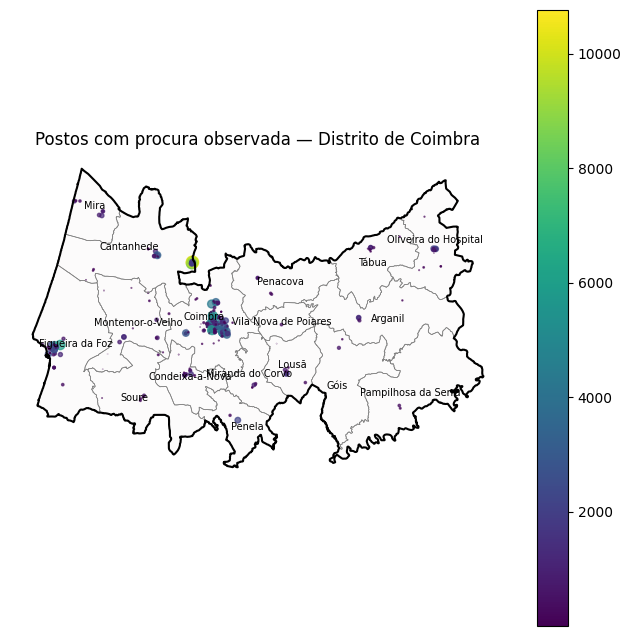

In [22]:
# Print do Mapa com os valores do distrito de Coimbra (usando map_utils.py)

municipio_analisar = munic.get_limites_distrito(DISTRITO, engine)

fig, ax = munic.plot_postos_distrito(
    distrito_analisar,
    DISTRITO,
    municipio_analisar,
    coluna_tamanho="n_sessoes",
    titulo=f"Postos com procura observada — Distrito de {DISTRITO}"
)

fig.savefig(
    FIG_DIR / f"postos_procura_{DISTRITO.lower()}.png",
    dpi=300,
    bbox_inches="tight"
)

(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'Postos com procura observada — Distrito de Coimbra'}>)

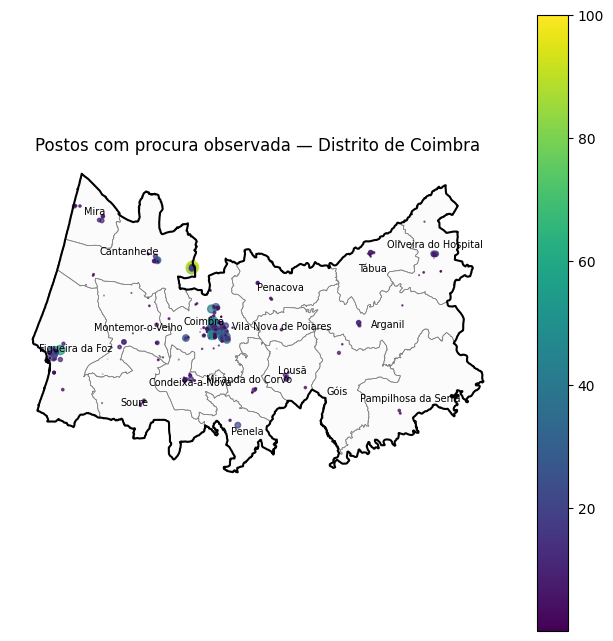

In [53]:
# Print do Mapa com valores de Coimbra

municipio_analisar = munic.get_limites_distrito(DISTRITO, engine)

distrito_analisar.head()

distrito_analisar["n_sessoes_scaled"] = distrito_analisar["n_sessoes"] / distrito_analisar["n_sessoes"].max() * 100 

munic.plot_postos_distrito(
    distrito_analisar,
    DISTRITO,
    municipio_analisar,
    coluna_tamanho="n_sessoes_scaled",
    titulo=f"Postos com procura observada — Distrito de {DISTRITO}"
)

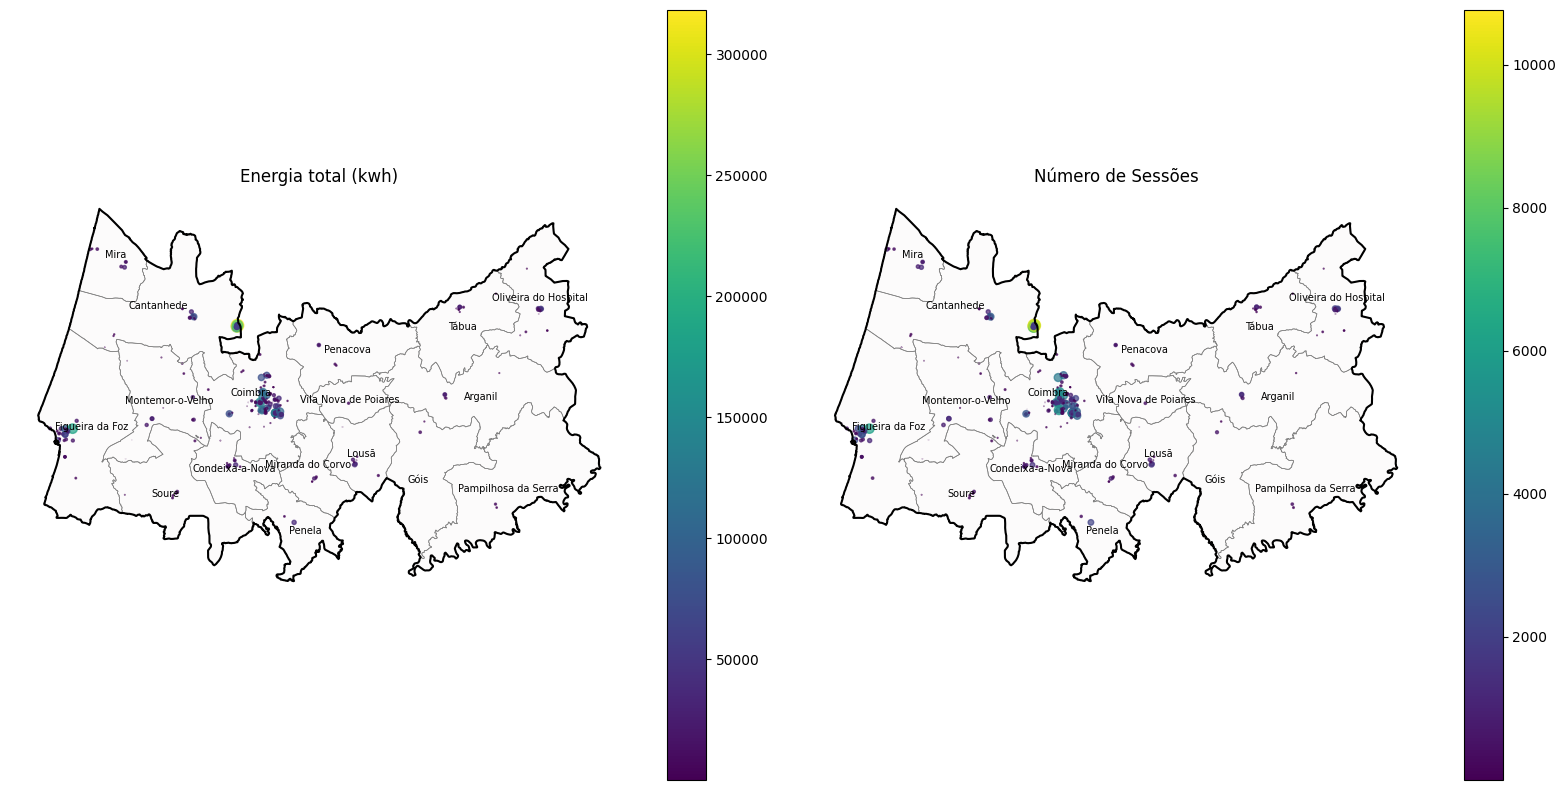

In [54]:
# Plot para mostrar onde há mais sessões e onde há mais consumo de energia: | Energia total (kWh) | Nº de sessões |
fig, axes = plt.subplots(
    1, 2,
    figsize=(16,8)
) 

# Mais consumo de energia
munic.plot_postos_distrito(
    distrito_analisar,
    DISTRITO,
    municipio_analisar,
    coluna_tamanho="energia_total_kwh",
    titulo="Energia total (kwh)",
    ax=axes[0]
)

# Mais sessões
munic.plot_postos_distrito(
    distrito_analisar,
    DISTRITO,
    municipio_analisar,
    coluna_tamanho="n_sessoes",
    titulo="Número de Sessões",
    
    ax=axes[1]
)

plt.tight_layout()

fig.savefig(
    FIG_DIR / f"energia_sessoes_{DISTRITO.lower()}.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()



In [26]:
# verificar a correlação entre as variáveis - validação dos gráficos acima
distrito_analisar[["energia_total_kwh", "n_sessoes"]].corr()

,energia_total_kwh,n_sessoes
energia_total_kwh,1.000000,0.974425
n_sessoes,0.974425,1.000000


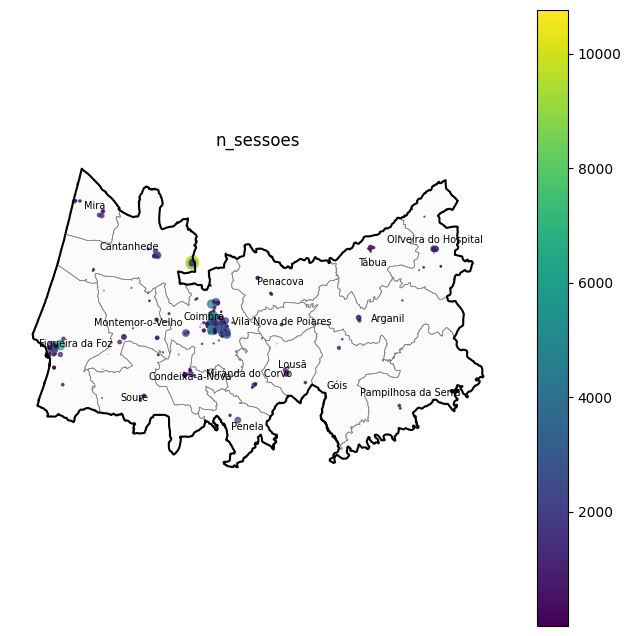

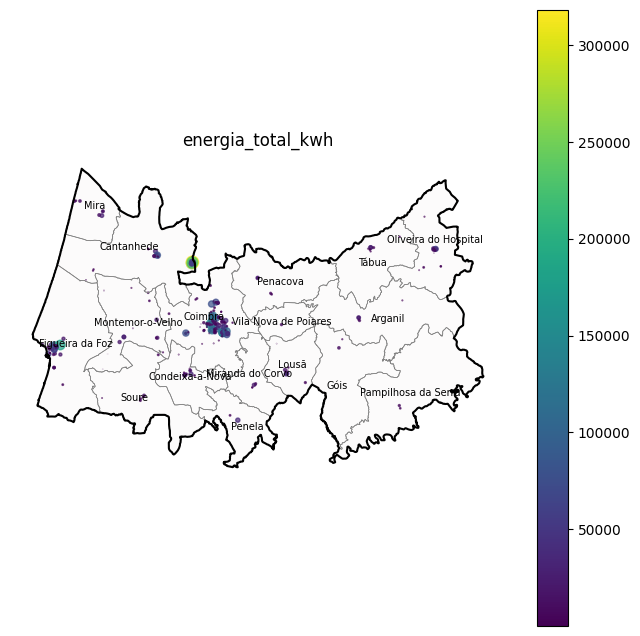

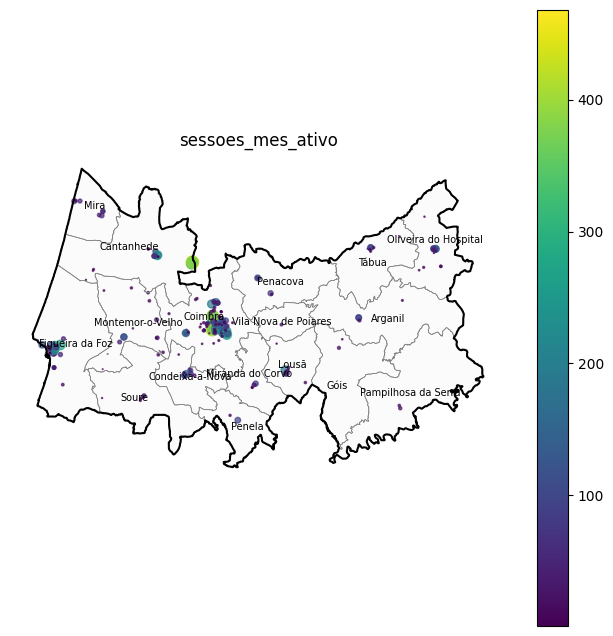

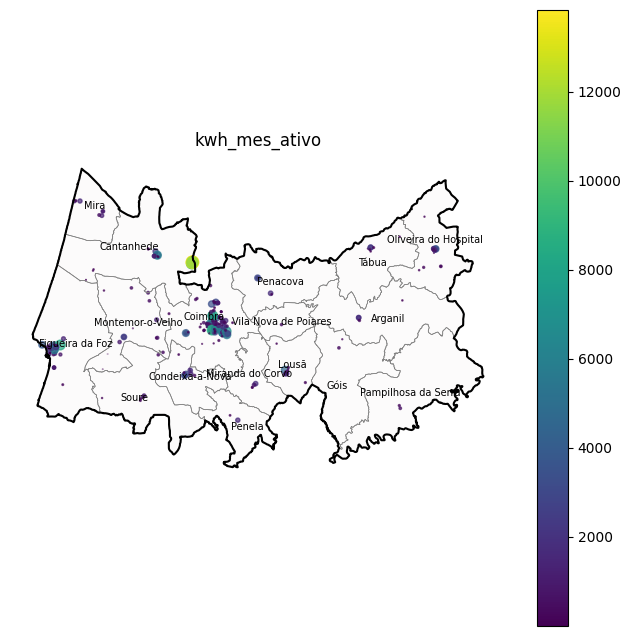

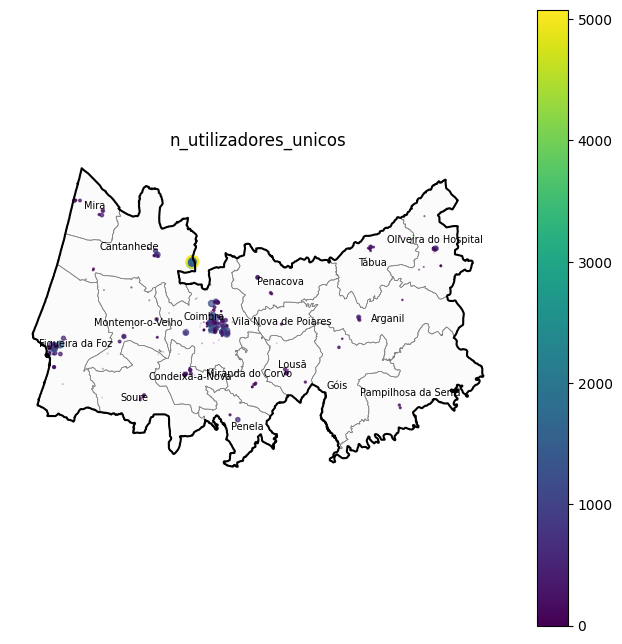

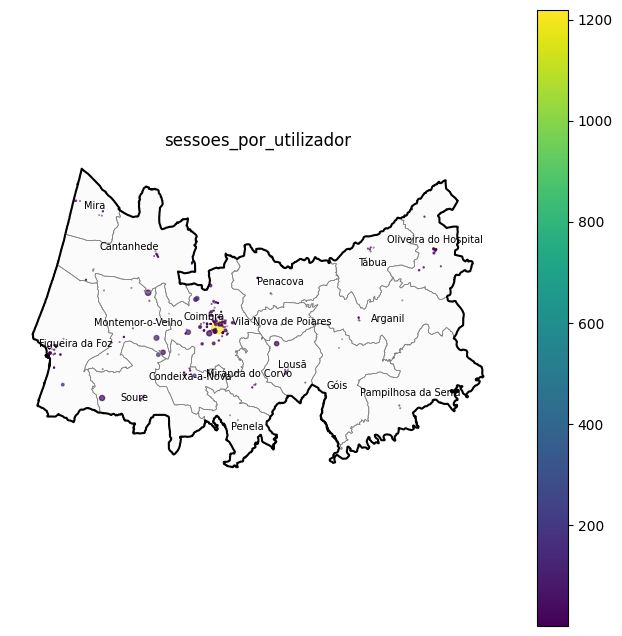

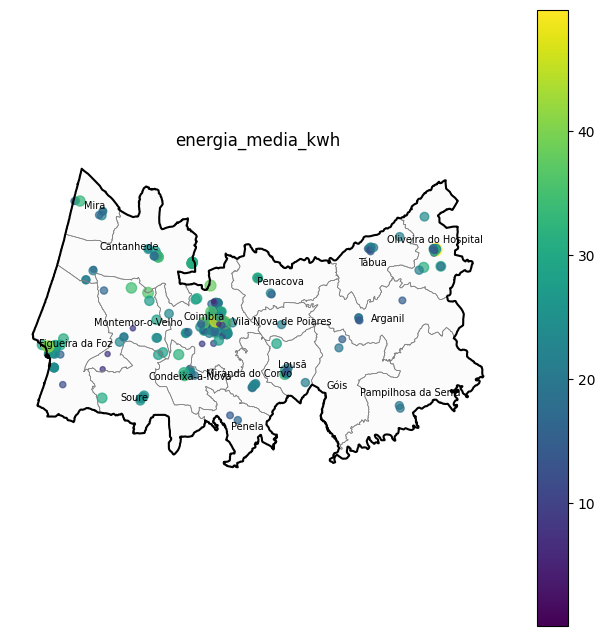

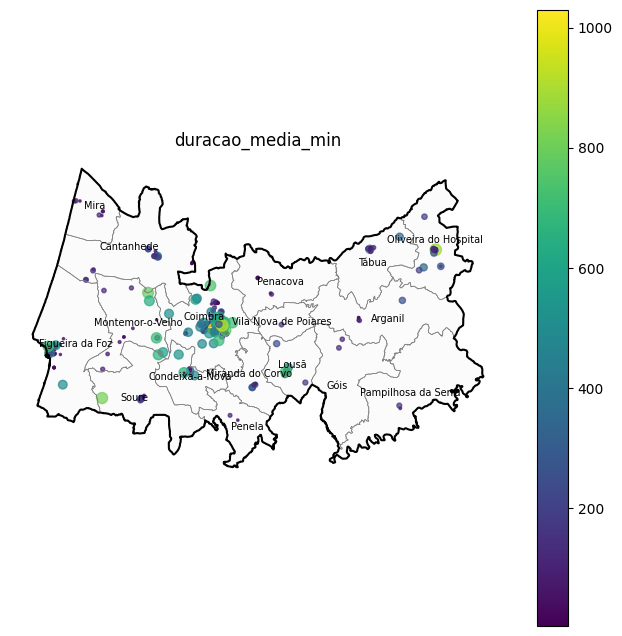

In [27]:
variaveis_mapa = [
    "n_sessoes",
    "energia_total_kwh",
    "sessoes_mes_ativo",
    "kwh_mes_ativo",
    "n_utilizadores_unicos",
    "sessoes_por_utilizador",
    "energia_media_kwh",
    "duracao_media_min"
]

for v in variaveis_mapa:
    munic.plot_postos_distrito(
        distrito_analisar,
        DISTRITO,
        municipio_analisar,
        coluna_tamanho=v,
        titulo=v
    )

In [29]:
# OUTPUT

output_dir = Path("../outputs")
(output_dir / "data").mkdir(parents=True, exist_ok=True)

postos_procura.to_parquet(output_dir / "data" / "postos_procura.parquet")
distrito_analisar.to_parquet(output_dir / "data" / "postos_procura_coimbra.parquet")

## 1.3 Portuguese public charging netwook overview - characterisation (Fotografia da rede)

### 1.3.1 Distribuição dos conectores pelo Terrritório

In [30]:
# query com todos os connectors - para já não vou inlcuir
query = """
    SELECT DISTINCT ON (p.connector_uid)
        p.id_charging_station,
        p.connector_uid,
        p.geom
    FROM v01_postos_unicos_continente_all_data p
"""

In [31]:
# query com todos os postos 16674
query = """
    SELECT DISTINCT ON (p.id_charging_station)
        p.id_charging_station,
        p.geom
    FROM v01_postos_unicos_continente_all_data p
    WHERE p.geom IS NOT NULL
    ORDER BY p.id_charging_station

"""

In [32]:
# ler como Geodataframe por causa dos dados espaciais
gdf_stations = gdf = gpd.read_postgis(query, con=engine, geom_col="geom")
print(gdf.shape)

(16674, 2)


In [33]:
# obter as separações dos municipios a partir da caop_2024

query_caop = "SELECT distrito, geom FROM v00_caop_municipios where nuts_1 = 'Continente' ;"

gdf_municipios = gpd.read_postgis(query_caop, con=engine, geom_col="geom")
gdf_municipios = gdf_municipios.to_crs(epsg=3763)

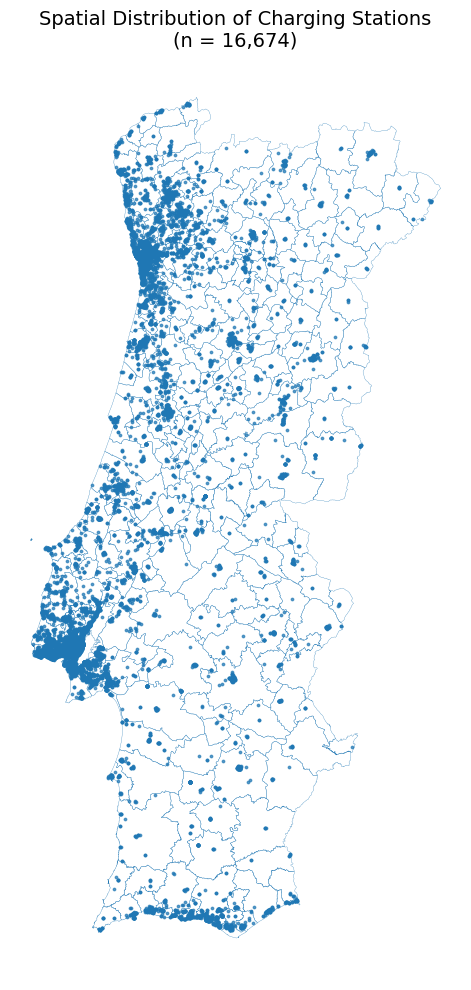

In [34]:
fig, ax = plt.subplots(figsize=(8, 10))

gdf_municipios.boundary.plot(
    ax=ax,
    linewidth=0.2
)

gdf_stations.plot(
    ax=ax,
    markersize=3,
    alpha=0.7
)

ax.set_title(
    f"Spatial Distribution of Charging Stations\n(n = {len(gdf_stations):,})",
    fontsize=14
)

ax.set_axis_off()

plt.tight_layout()

fig.savefig(
    FIG_DIR / "mapa_4_1_1_charging_stations_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

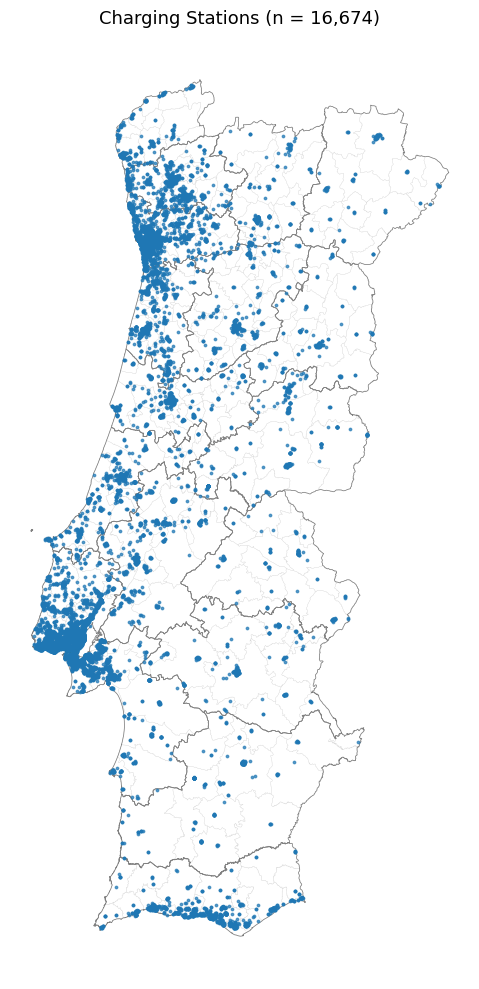

In [35]:
munic.plot_categories_with_boundaries(
    gdf_points=gdf_stations,
    column="id_charging_station",
    title=f"Charging Stations (n = {len(gdf_stations):,})",
    outfile="mapa_4_1_1_charging_stations_distribution.png",
    gdf_mun=gdf_municipios
)

Postos no distrito de Coimbra: 285


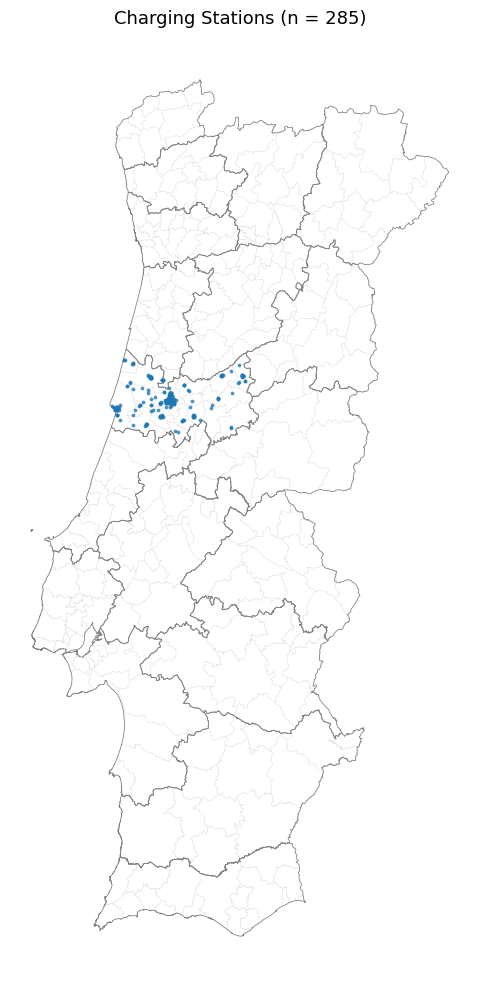

In [36]:
DISTRITO = "Coimbra"

gdf_coimbra = postos_procura[
    postos_procura["distrito"]
    .str.upper()
    .eq(DISTRITO.upper())
].copy()

print(f"Postos no distrito de Coimbra: {len(gdf_coimbra):,}")


munic.plot_categories_with_boundaries(
    gdf_points=gdf_coimbra,
    column="id_charging_station",
    title=f"Charging Stations (n = {len(gdf_coimbra):,})",
    outfile="mapa_4_1_1_charging_stations_distribution.png",
    gdf_mun=gdf_municipios
)

In [37]:
# --------------------------------------------------
# Query auxiliar para os mapas com distrito
# --------------------------------------------------
query_caop = """
    SELECT
        distrito,
        municipio,
        geom
    FROM v00_caop_municipios
    WHERE nuts_1 = 'Continente'
"""

gdf_municipios_ = read_gdf(
    query_caop,
    geom_col="geom"
).to_crs(epsg=3763)

print(gdf_municipios_.shape)
print(gdf_municipios_.crs)

(278, 3)
EPSG:3763


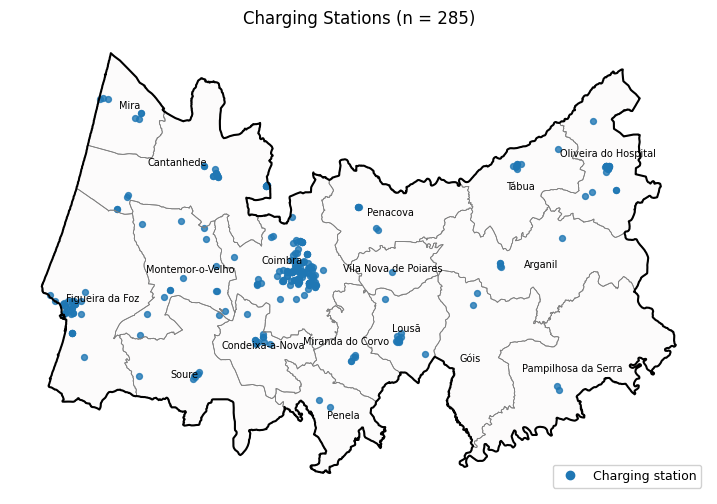

In [38]:
# ------------------------------------------------
#       Mapa para Case Studie Coimbra 
#               4.6.1 fig.1
#-------------------------------------------------

gdf_municipios_coimbra = gdf_municipios_[
    gdf_municipios_["distrito"]
    .str.upper()
    .eq("COIMBRA")
].copy() 

# Formatação em inglês: 285 (ou 1,285 com vírgula para milhares)
n_stations = f"{len(gdf_coimbra):,}".replace(",", ",")

fig, ax = munic.plot_categorias_distrito(
    gdf_postos=gdf_coimbra,
    gdf_municipios=gdf_municipios_coimbra,
    distrito=DISTRITO,
    coluna=None,
    titulo = f"Charging Stations (n = {len(gdf_coimbra):,})",
    labels=True,
    markersize=18,
    alpha=0.8
)
# Adicionar elemento de legenda em inglês (caso a função não crie automaticamente)
import matplotlib.lines as mlines

charging_station_marker = mlines.Line2D(
    [], [], 
    color='#1f77b4', 
    marker='o', 
    linestyle='None',
    markersize=6, 
    label='Charging station'
)

# Adicionar a legenda no canto inferior direito/esquerdo
ax.legend(
    handles=[charging_station_marker],
    loc='lower right',
    frameon=True,
    facecolor='white',
    framealpha=0.9,
    fontsize=9
)

fig.savefig(
    FIG_DIR / "mapa_charging_stations_distribution_coimbra_nb01.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

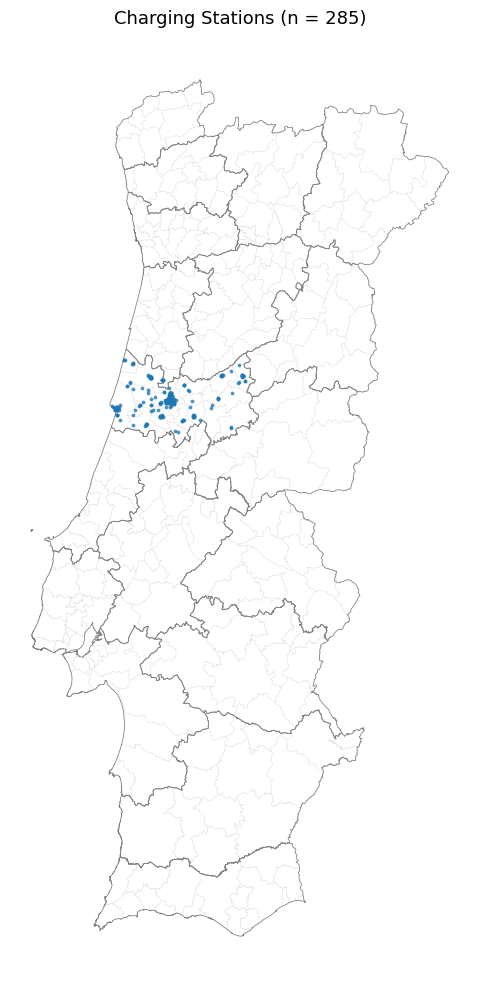

In [39]:

munic.plot_categories_with_boundaries(
    gdf_points=gdf_coimbra,
    column="id_charging_station",
    title=f"Charging Stations (n = {len(gdf_coimbra):,})",
    outfile="mapa_4_1_1_charging_stations_distribution.png",
    gdf_mun=gdf_municipios
)

### 1.3.2 Distribuição dos conectores agrupados por tipos de potência no Terrritório

In [41]:
# query com todos os Power_TYPE
query = """
    SELECT DISTINCT ON (p.connector_uid)
        p.connector_uid,
        p.power_type,
        p.geom
    FROM v01_postos_unicos_continente_all_data p
    WHERE p.geom IS NOT NULL
    ORDER BY p.connector_uid
    """

In [42]:
gdf_power = gpd.read_postgis(query, con=engine, geom_col="geom")
print(gdf_power.shape)

(33288, 3)


In [43]:
#from libs.map_utils import get_limites_distrito, plot_postos_distrito
import importlib
import libs.map_utils as munic
#importlib.reload(libs.map_utils)
importlib.reload(munic)

<module 'libs.map_utils' from '/Users/paulorelvas/Documents/mestrado/tese/python_support/backup_original_all_my_tese_mobi_postgresql/libs/map_utils.py'>

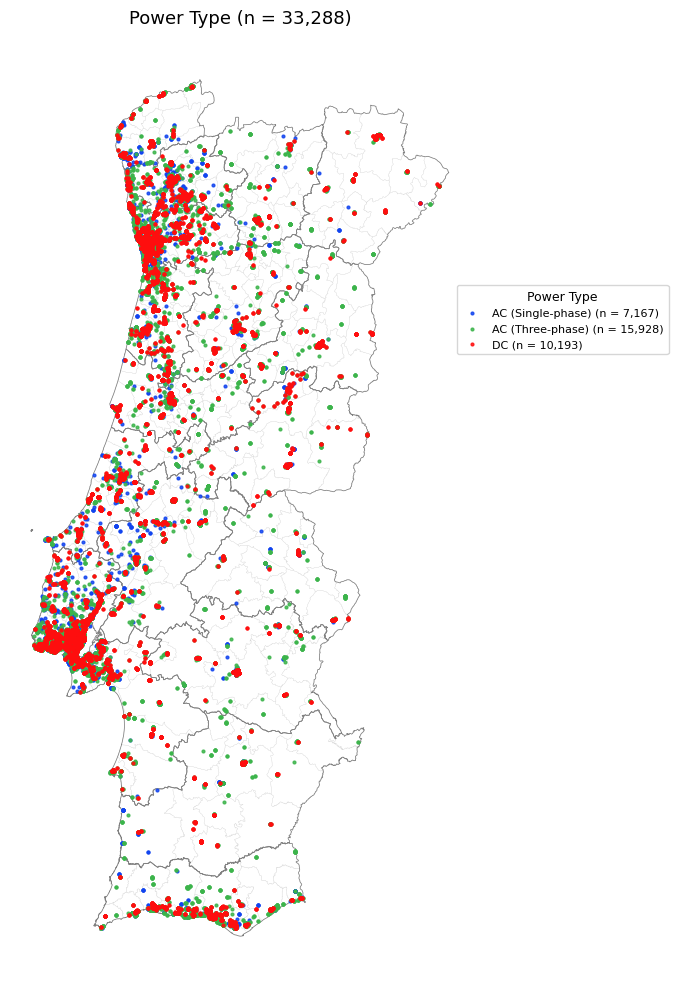

In [44]:
# plot com todos os Power_TYPE
colors = {
    "AC_1_PHASE": "#1144ef",   # verde
    "AC_3_PHASE": "#3cb44b", # "#52ff0e",   # amarelo
    "DC": "#ff0e0e"            # vermelho
}
labels = {
    "AC_1_PHASE": "AC (Single-phase)",
    "AC_3_PHASE": "AC (Three-phase)",
    "DC": "DC"
}

munic.plot_categories_with_boundaries(
    gdf_points=gdf_power,
    column="power_type",
    colors=colors,
    labels=labels,
    ncols=3,
    title=f"Power Type (n = {len(gdf_power):,})",
    outfile="mapa_4_1_1_power_type_distribution_v1.png",
    gdf_mun=gdf_municipios
)

### 1.3.3 Distribuição dos conectores agrupados por tipo de standard no Terrritório

In [45]:
# query com todos os STANDARD
query = """
    SELECT DISTINCT ON (p.connector_uid)
        p.connector_uid,
        p.standard,
        p.geom
    FROM v01_postos_unicos_continente_all_data p
    WHERE p.geom IS NOT NULL
    ORDER BY p.connector_uid
"""

In [46]:
gdf_standard = gpd.read_postgis(query, con=engine, geom_col="geom")
print(gdf_standard.shape)

(33288, 3)


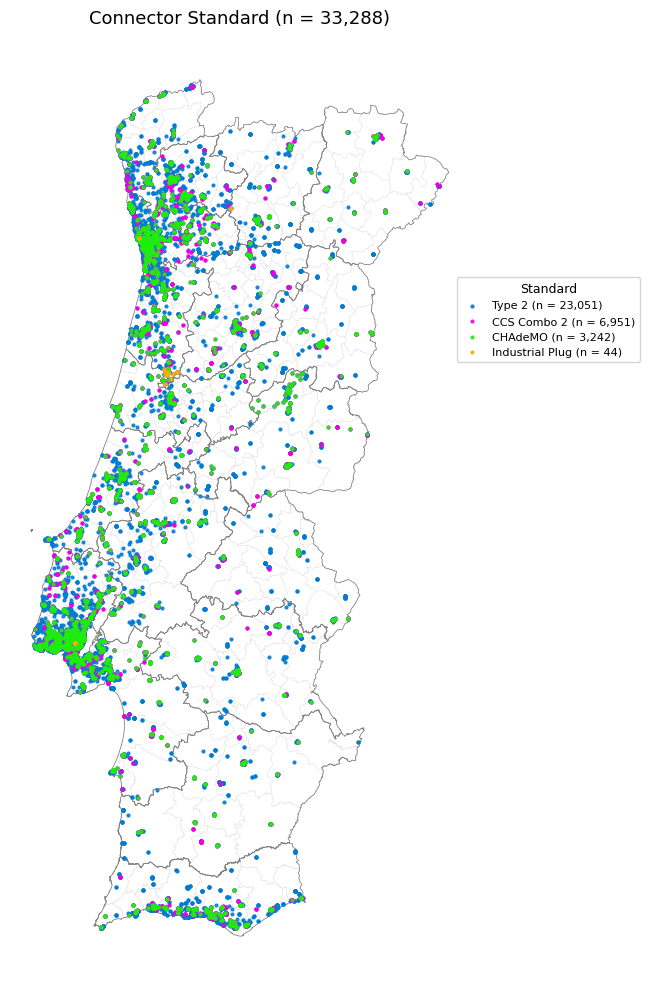

In [47]:
# plot com todos os Standard TYPE
colors = {
    "IEC_62196_T2": "#007bd3",          # azul
    "IEC_62196_T2_COMBO": "#ed01e1",    # roxo
    "CHADEMO": "#1DEE0E",               # verde
    "IEC_60309_2_single_16": "#ffa70e"  # laranja
}
labels = {
    "IEC_62196_T2": "Type 2",
    "IEC_62196_T2_COMBO": "CCS Combo 2",
    "CHADEMO": "CHAdeMO",
    "IEC_60309_2_single_16": "Industrial Plug"
}

munic.plot_categories_with_boundaries(
    gdf_points=gdf_standard,
    column="standard",
    colors=colors,
    labels=labels,
    title=f"Connector Standard (n = {len(gdf_power):,})",
    outfile="mapa_4_1_1_standard_type_distribution_v1.png",
    gdf_mun=gdf_municipios
)

### 1.3.4 Distribuição dos conectores agrupados por formato de ligação no Terrritório

In [48]:
# query com tipos deFORMAT
query = """
    SELECT DISTINCT ON (p.connector_uid)
        p.connector_uid,
        p.format,
        p.geom
    FROM v01_postos_unicos_continente_all_data p
    WHERE p.geom IS NOT NULL
    ORDER BY p.connector_uid
"""



In [49]:
gdf_format = gpd.read_postgis(query, con=engine, geom_col="geom")
print(gdf_format.shape)

(33288, 3)


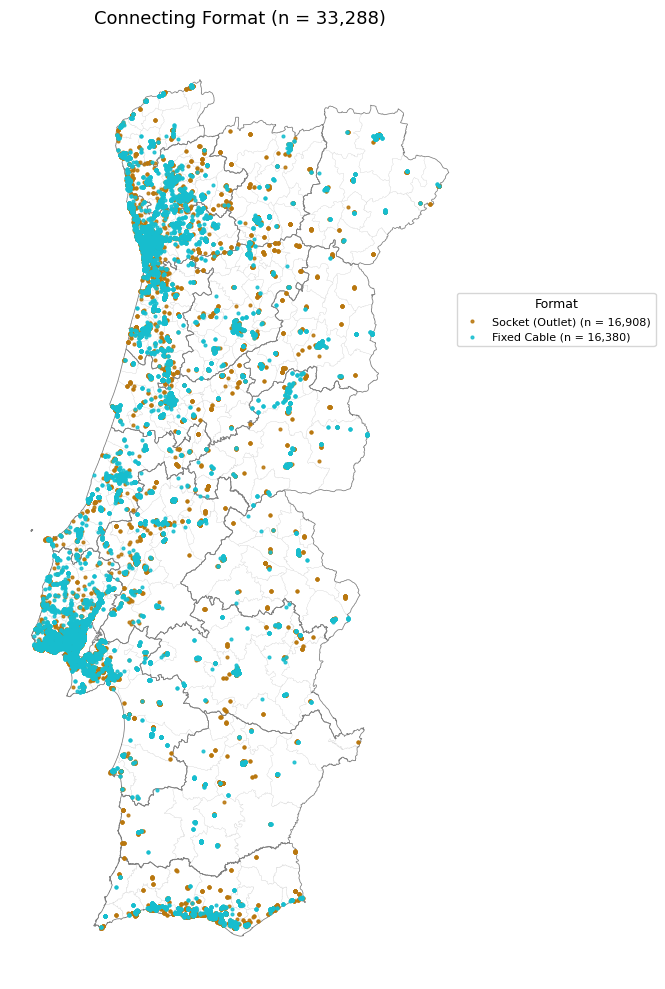

In [50]:
# plot com todos os Format
colors = {
    "SOCKET": "#b9770e",
    "CABLE": "#17becf"
}
labels = {
    "SOCKET": "Socket (Outlet)",
    "CABLE": "Fixed Cable"
}

munic.plot_categories_with_boundaries(
    gdf_points=gdf_format,
    column="format",
    colors=colors,
    labels=labels,
    title=f"Connecting Format (n = {len(gdf_power):,})",
    outfile="mapa_4_1_1_format_type_distribution_v1.png",
    gdf_mun=gdf_municipios
)